# Modélisation des unités de production électriques

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## PV

### Collecte de données

Jointures des données météos du [CAMS](https://ads.atmosphere.copernicus.eu/datasets/cams-solar-radiation-timeseries?tab=download) et de [Météo France]((https://explore.data.gouv.fr/fr/datasets/6569b51ae64326786e4e8e1a/#/resources/daf5843a-7d1e-4b41-bf8e-220fddffa7ed)) (2022-2025) nécessaires pour le modèles PV. Les données du CAMS sont sur une base 1 minute mais celles de météo france relative à la température sont de base horaire. La date des mesures est exprimées un UTC pour les deux datasets ce qui permet la joiture. 

In [3]:
df_cams = pd.read_csv("static/1a2e643f14c2bb36ef23f1d83bfd768.csv", sep=";")
df_cams["time"] = pd.to_datetime(df_cams["Observation period"].str.split("/").str[1])
df_cams.drop(columns=["Observation period"], inplace=True)
df1 = pd.read_csv("static/83543052-f2c7-4864-b75d-55bc5f31459c.csv")
df2 = pd.read_csv("static/royan_meteo_heure-2020-2023.csv")
df3 = pd.read_csv("static/royan_meteo_heure-2024-2025.csv")

df_mf = pd.concat([df1, df2, df3], ignore_index=True)

df_mf = df_mf.drop_duplicates(subset=['AAAAMMJJHH'])

df_mf.reset_index(drop=True, inplace=True)

df_mf["time"] = pd.to_datetime(df_mf["AAAAMMJJHH"], format="%Y%m%d%H")

df_cams = df_cams.merge(df_mf[["time", "T"]], on="time", how="left")

df_cams.set_index("time", inplace=True)
df_cams["T"] = df_cams["T"].interpolate(method="time", limit_direction="both")

FileNotFoundError: [Errno 2] No such file or directory: 'static/1a2e643f14c2bb36ef23f1d83bfd768.csv'

In [ ]:
df_cams.to_csv("static/pv_historical_data-2022_2025", sep=",")

### Vérification des données

In [ ]:
df = pd.read_csv("static/pv_historical_data-2022_2025.csv")
df["time"] = pd.to_datetime(df["time"])
df["T"] = pd.to_numeric(df["T"], errors="coerce")

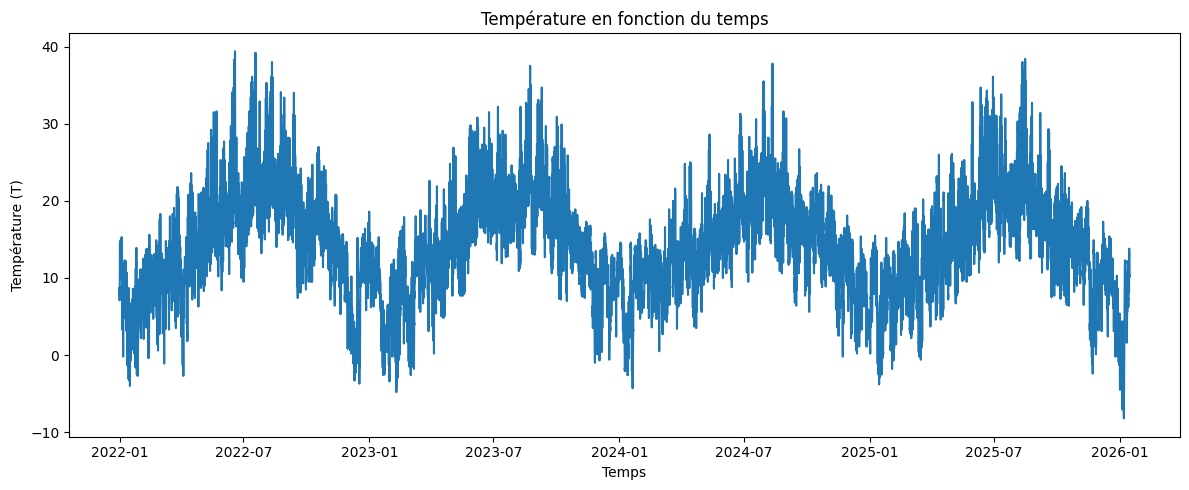

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df["time"], df["T"])
plt.xlabel("Temps")
plt.ylabel("Température (T)")
plt.title("Température en fonction du temps")
plt.tight_layout()
plt.show()

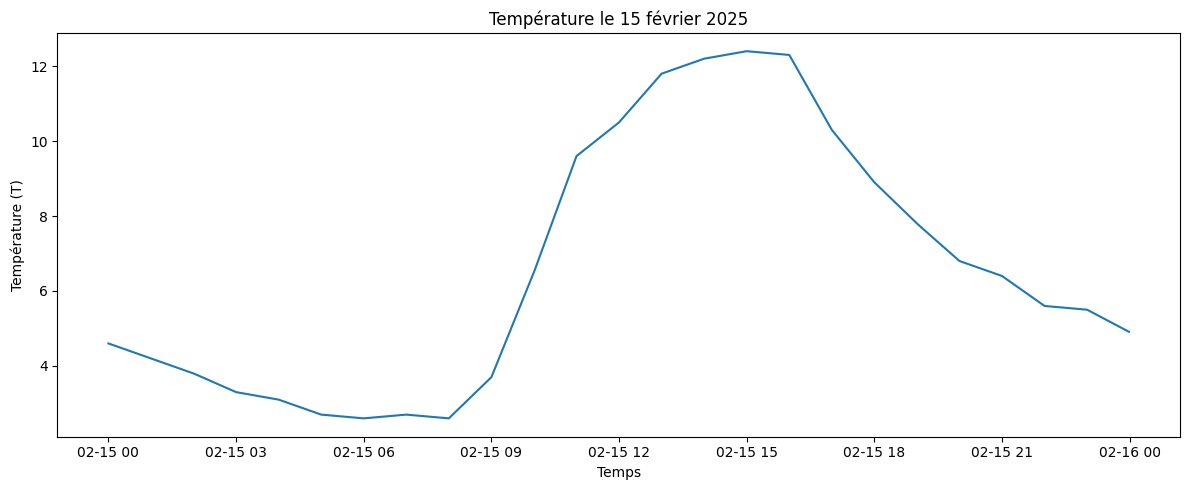

In [ ]:
mask = (df["time"] >= "2025-02-15") & (df["time"] < "2025-02-16")
plt.figure(figsize=(12, 5))
plt.plot(df.loc[mask, "time"], df.loc[mask, "T"])
plt.xlabel("Temps")
plt.ylabel("Température (T)")
plt.title("Température le 15 février 2025")
plt.tight_layout()
plt.show()

In [ ]:
df["T"].isna().sum()

np.int64(0)

Notre interpolation de la température semble focntionnelle

### Simulation de la production

In [4]:
from config import Config

c = Config()

from components import PowerProductionManager

start = pd.Timestamp("2022-01-01 00:00")
end = pd.Timestamp("2025-12-31 23:00")
power_production_manager = PowerProductionManager(c)
df = power_production_manager.simmulate_historical_power_production(start, end)

ModuleNotFoundError: No module named 'pvlib'

In [ ]:
df["sp_power"].describe()

count    2.103780e+06
mean     9.006788e-01
std      1.377269e+00
min      0.000000e+00
25%      0.000000e+00
50%      3.243842e-03
75%      1.428049e+00
max      5.411166e+00
Name: sp_power, dtype: float64

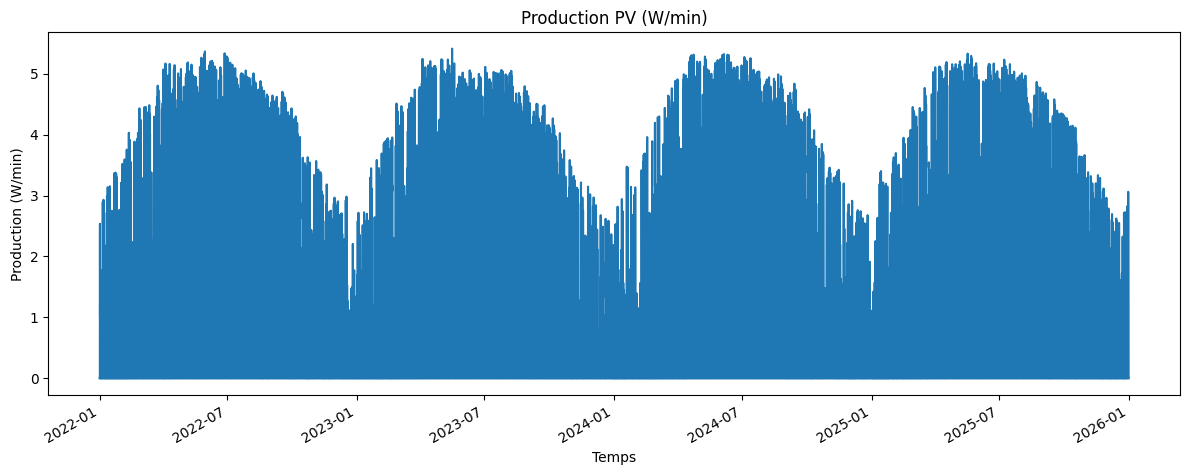

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["sp_power"])
plt.xlabel("Temps")
plt.ylabel("Production (W/min)")
plt.title("Production PV (W/min)")
plt.tight_layout()
plt.gcf().autofmt_xdate()
plt.show()

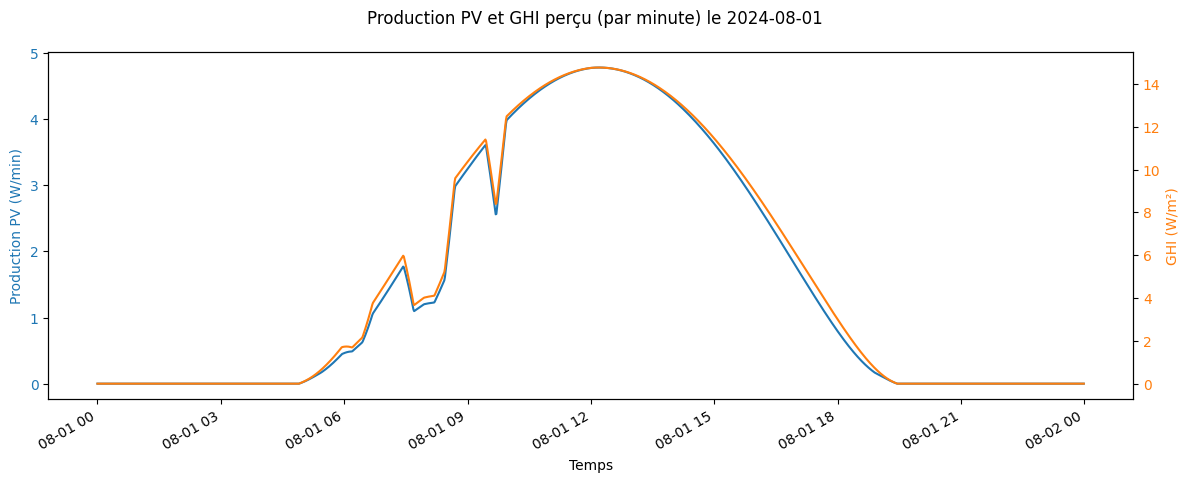

In [ ]:
date = "2024-08-01"
mask = df.index.strftime("%Y-%m-%d") == date
df_ = df.loc[mask, ["sp_power", "GHI"]]
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(df_.index, df_["sp_power"], color="tab:blue", label="Production PV (W/min)")
ax1.set_xlabel("Temps")
ax1.set_ylabel("Production PV (W/min)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(df_.index, df_["GHI"], color="tab:orange", label="GHI")
ax2.set_ylabel("GHI (W/m²)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

fig.suptitle(f"Production PV et GHI perçu (par minute) le {date}")
fig.tight_layout()
fig.autofmt_xdate()
plt.show()

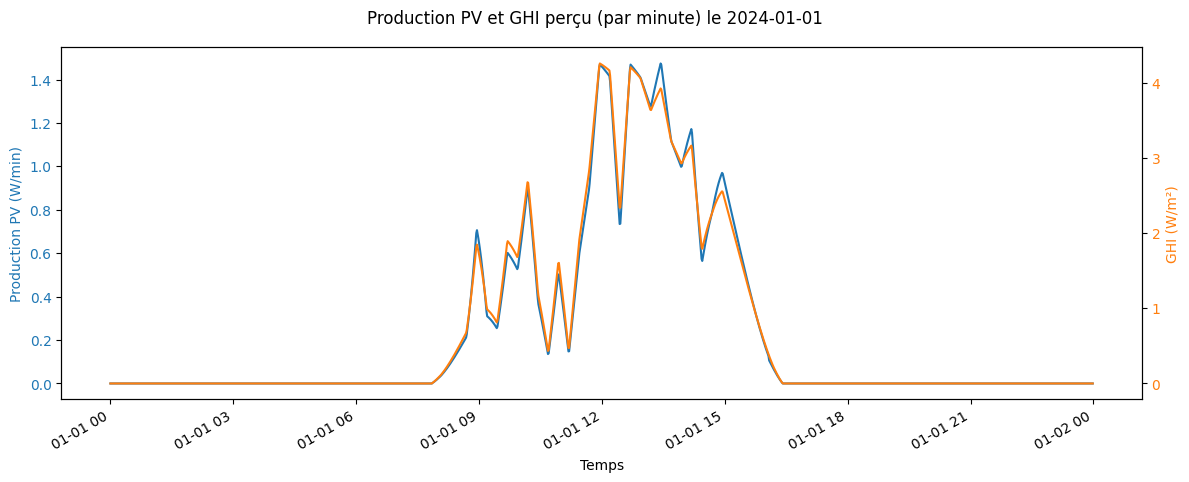

In [ ]:
date = "2024-01-01"
mask = df.index.strftime("%Y-%m-%d") == date
df_ = df.loc[mask, ["sp_power", "GHI"]]
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(df_.index, df_["sp_power"], color="tab:blue", label="Production PV (W/min)")
ax1.set_xlabel("Temps")
ax1.set_ylabel("Production PV (W/min)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(df_.index, df_["GHI"], color="tab:orange", label="GHI")
ax2.set_ylabel("GHI (W/m²)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

fig.suptitle(f"Production PV et GHI perçu (par minute) le {date}")
fig.tight_layout()
fig.autofmt_xdate()
plt.show()

Sans mises à l'echelle

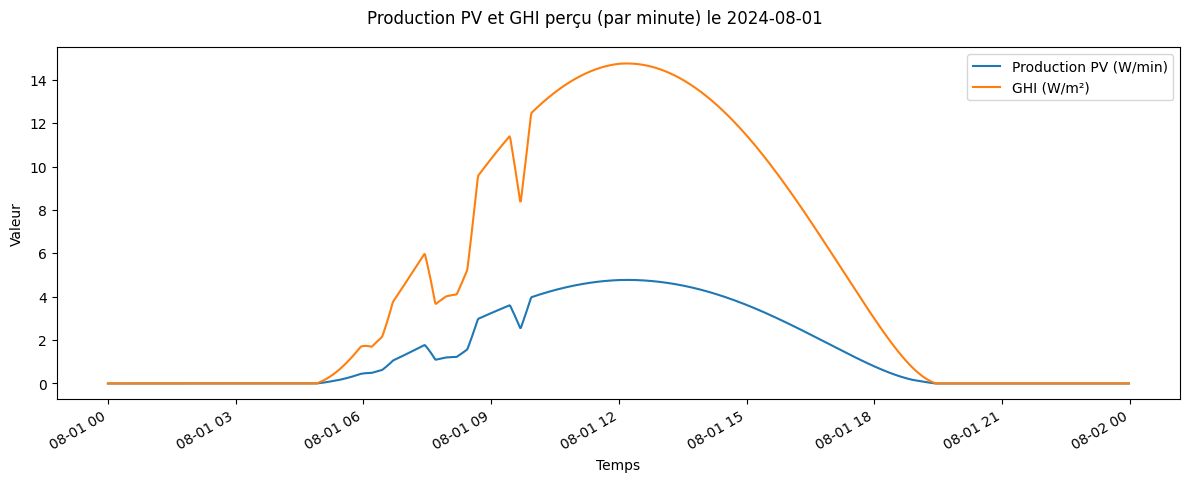

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_.index, df_["sp_power"], color="tab:blue", label="Production PV (W/min)")
ax.plot(df_.index, df_["GHI"], color="tab:orange", label="GHI (W/m²)")
ax.set_xlabel("Temps")
ax.set_ylabel("Valeur")
ax.legend()
fig.suptitle(f"Production PV et GHI perçu (par minute) le {date}")
fig.tight_layout()
fig.autofmt_xdate()
plt.show()


In [ ]:
df["GHI"].describe()

count    2.103780e+06
mean     2.725851e+00
std      4.154951e+00
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e-02
75%      4.333900e+00
max      1.645810e+01
Name: GHI, dtype: float64

In [ ]:
df["sp_efficiency"] = df["sp_power"] / (df["GHI"])

In [ ]:
df["sp_efficiency"].describe()

count    1.055252e+06
mean     3.240717e-01
std      4.560632e-02
min      1.041369e-01
25%      3.045433e-01
50%      3.150884e-01
75%      3.384018e-01
max      4.723944e-01
Name: sp_efficiency, dtype: float64

Le rendement moyen de notre panneau solaire est de 32% selon le modèle établi contre 15,67 % annoncé par le constructeur. Notre modèle n'est donc pas réaliste avec la configuration actuelle des variables. Mon hypothèse est que le l_syst ne peut pas être de 0, il nous faut donc le déterminer. 

A terme, afin de valider qui de notre modèle ou d'un simple modèle GHI*rendement module est le plus pertinent il nous faudrait des données expérimentales. De plus le modèle actuel ne prends pas compte dynamiquement de la dégradation des performances du panneau solaire dû aux embruns, au veillissement des cellules etc. En pratique un modèle de machine learning pourrrait être optimal. 

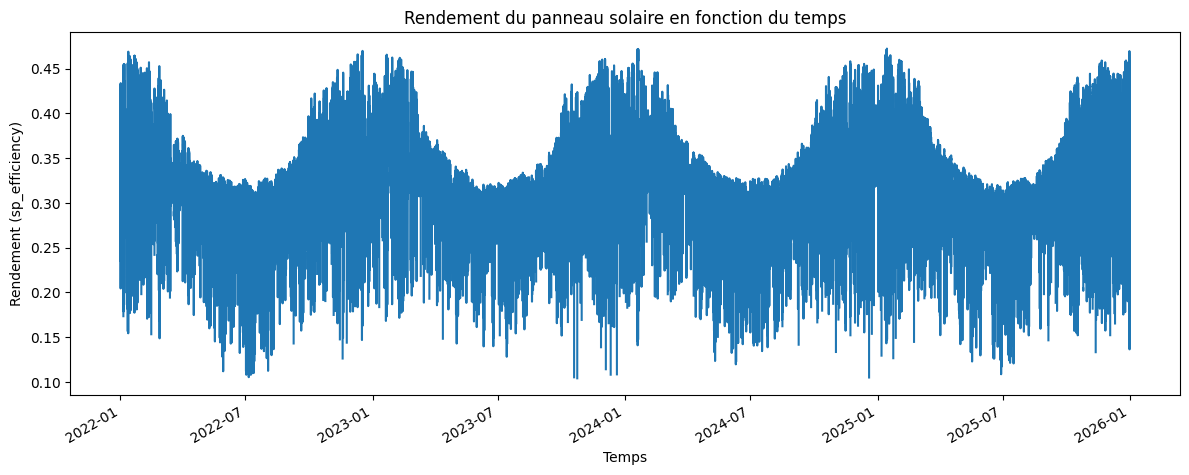

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["sp_efficiency"])
plt.xlabel("Temps")
plt.ylabel("Rendement (sp_efficiency)")
plt.title("Rendement du panneau solaire en fonction du temps")
plt.tight_layout()
plt.gcf().autofmt_xdate()
plt.show()

Il est surprenant de voir que le rendement du panneau solaire est fortement dépednant de la période de l'année. Je pense qu'une erreur de modélisation s'est glissée dans quelque part. 

### Simulation de la production d'une éolienne


In [ ]:
from config import Config

c = Config()

from components import PowerProductionManager

start = pd.Timestamp("2022-01-01 00:00")
end = pd.Timestamp("2025-12-31 23:00")
power_production_manager = PowerProductionManager(c)
df = power_production_manager.simulate_historical_wind_power_production(start, end)
print(df)

ModuleNotFoundError: No module named 'pvlib'